In [2]:
from google.colab import files
import pandas as pd

# Ask user to upload the file from their computer
uploaded = files.upload()

# Automatically get the uploaded filename
filename = list(uploaded.keys())[0]

# Read the CSV file
df = pd.read_csv(filename)

print("✅ File successfully loaded!")
print("Filename:", filename)
print("Shape:", df.shape)
df.head()


Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv
✅ File successfully loaded!
Filename: diabetes_prediction_dataset.csv
Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
# Check general information
df.info()

# Describe numerical columns
df.describe()

# Check how many positive and negative cases there are
print(df['diabetes'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
diabetes
0    91500
1     8500
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separate features (X) and target (y)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Convert categorical features to numeric (e.g., "gender")
X = pd.get_dummies(X, drop_first=True)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Standardize the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train size: (70000, 13)
Test size: (30000, 13)


In [6]:
from sklearn.linear_model import LogisticRegression

# Create and train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

print("✅ Model trained successfully!")


✅ Model trained successfully!


Accuracy: 0.96


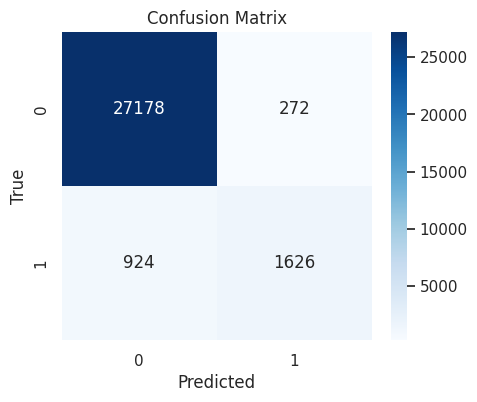


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27450
           1       0.86      0.64      0.73      2550

    accuracy                           0.96     30000
   macro avg       0.91      0.81      0.85     30000
weighted avg       0.96      0.96      0.96     30000



In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


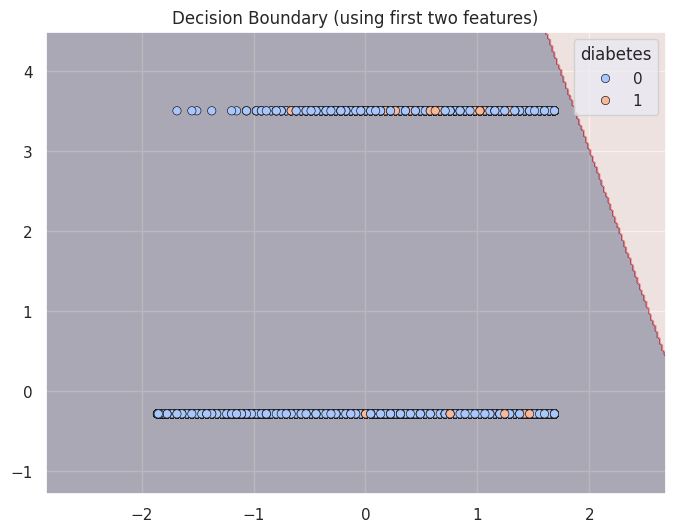

In [8]:
import numpy as np

# Example: using only the first two features for visualization
X_vis = X_train_scaled[:, :2]
y_vis = y_train

model_vis = LogisticRegression(max_iter=1000)
model_vis.fit(X_vis, y_vis)

# Create grid
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on grid
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_vis[:,0], y=X_vis[:,1], hue=y_vis, palette='coolwarm', edgecolor='k')
plt.title('Decision Boundary (using first two features)')
plt.show()


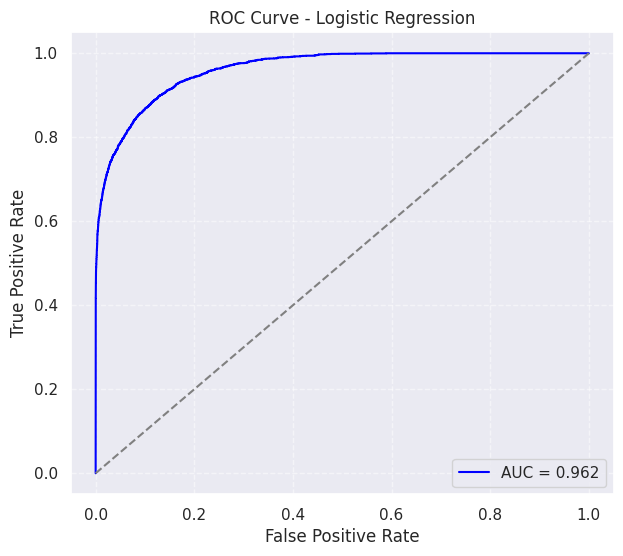

✅ ROC Curve plotted successfully. AUC = 0.962


In [9]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Get the probabilities for the positive class (1)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

# Calculate the AUC (Area Under the Curve)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"✅ ROC Curve plotted successfully. AUC = {auc:.3f}")
